# Modeling


In [12]:
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
import seaborn as sns

# ML
import xgboost as xgb
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import accuracy_score, confusion_matrix, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance
from hyperopt import STATUS_OK, Trials, fmin, hp, tpe 
import shap

# DR
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import Isomap

## 1. Prepare data for model

In [2]:
# Load prepared data
df = pd.read_csv('data/output/26_03_04.csv')

uneven class distributions -> stratified train-test-split required

In [ ]:
# Split into features and targets
X = df.drop(['other_events', 'vpre', 'vdist', 'vpost', 'resilience', 'resistance',
       'recovery', 'n_days_vdist', 'kndvi_anomaly_strength',
       'kndvi_anomaly_strength_average', 'veg_class', 'event_label', 'recovery_dep'], axis=1)


# Ohne t2min, t2mmax
'''X = df.drop(['other_events', 'vpre', 'vdist', 'vpost', 'resilience', 'resistance',
       'recovery', 'n_days_vdist', 'kndvi_anomaly_strength',
       'kndvi_anomaly_strength_average', 'veg_class', 'event_label', 'recovery_dep', 
       't2min_anomaly', 't2mmax_anomaly', 't2mmax', 't2mmin', 't2mmax_prev', 't2mmin_prev'], axis=1)'''

# with anomalies
'''X = df.drop(['other_events', 'vpre', 'vdist', 'vpost', 'resilience', 'resistance',
       'recovery', 'n_days_vdist', 'kndvi_anomaly_strength',
       'kndvi_anomaly_strength_average', 'veg_class', 'event_label', 'recovery_dep',
       't2m_anomaly', 't2min_anomaly', 't2mmax_anomaly', 'prec_anomaly', 'soil_moist_anomalies', 'evap_anomaly', 'evap_pot_anomalies'], axis=1)'''


y_resl = df['resilience']
y_rest = df['resistance']
y_rec = df['recovery']
y_anom = df['kndvi_anomaly_strength_average']

# Split into train and test set
X_train_resl, X_test_resl, y_train_resl, y_test_resl = train_test_split(X, y_resl, test_size=0.2, random_state=123, stratify=df['veg_class']) # Resilience
X_train_rest, X_test_rest, y_train_rest, y_test_rest = train_test_split(X, y_rest, test_size=0.2, random_state=123, stratify=df['veg_class']) # Resistance
X_train_rec, X_test_rec, y_train_rec, y_test_rec = train_test_split(X, y_rec, test_size=0.2, random_state=123, stratify=df['veg_class']) # Recovery
X_train_anom, X_test_anom, y_train_anom, y_test_anom = train_test_split(X, y_anom, test_size=0.2, random_state=123, stratify=df['veg_class']) # Anomaly strength


## 2. Dimensionality reduction
### Standardize data
This is done to ensure that PCA treats all data equally since mean = 0 and sd = 1.

In [16]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_resl)

## A) PCA

In [17]:
pca = PCA(n_components=5)
X_resl_pca = pca.fit_transform(X_train_scaled)

### Explained variance

In [18]:
print("Explained variance:", pca.explained_variance_ratio_)
print("Cumulative:", np.cumsum(pca.explained_variance_ratio_))

Explained variance: [0.37266458 0.18260435 0.12711086 0.08304836 0.04931178]
Cumulative: [0.37266458 0.55526893 0.68237979 0.76542815 0.81473993]


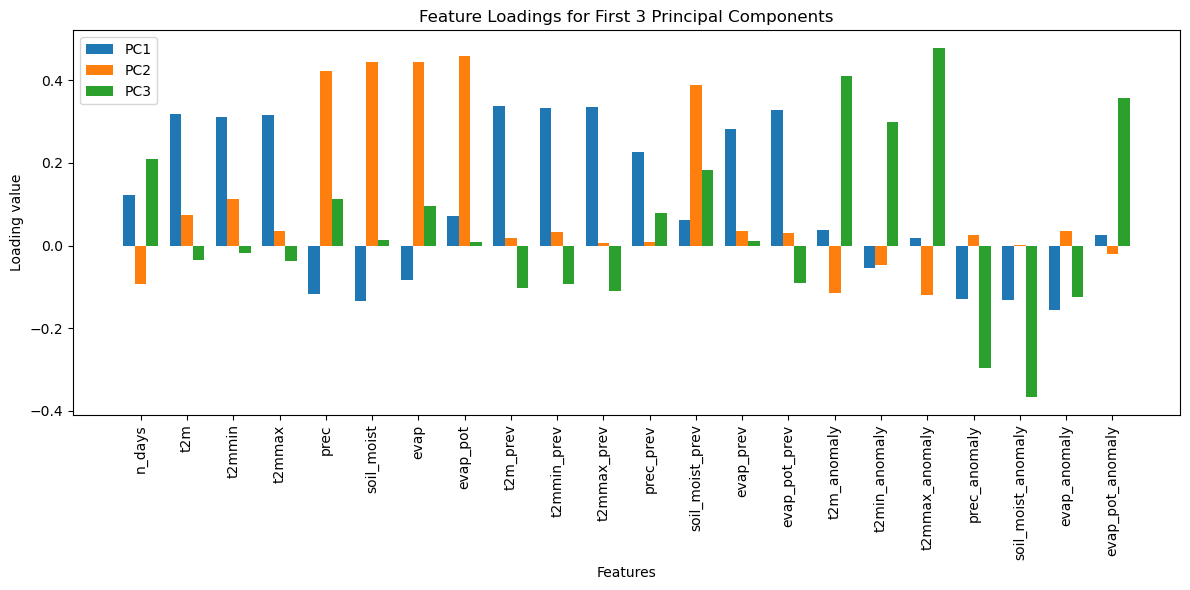

In [19]:
feature_names  = X_train_resl.columns

# Get PCA loadings (components)
loadings = pca.components_.T  # shape = [n_features, n_components]

# Create a DataFrame for easier plotting
loadings_df = pd.DataFrame(loadings, index=feature_names,
                           columns=[f'PC{i+1}' for i in range(pca.n_components_)])

plt.figure(figsize=(12, 6))
for i in range(3):  # first 3 PCs
    plt.bar(np.arange(len(feature_names)) + i*0.25, loadings_df[f'PC{i+1}'], 
            width=0.25, label=f'PC{i+1}')
plt.xticks(np.arange(len(feature_names)) + 0.25, feature_names, rotation=90)
plt.xlabel('Features')
plt.ylabel('Loading value')
plt.title('Feature Loadings for First 3 Principal Components')
plt.legend()
plt.tight_layout()
plt.show()


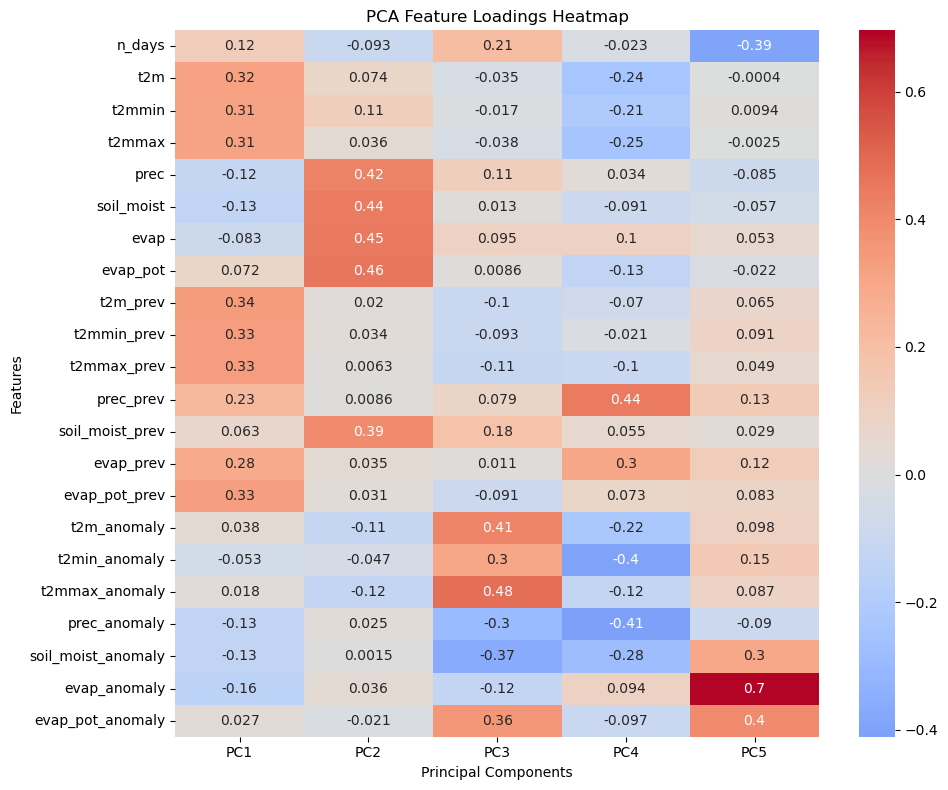

In [20]:
# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(loadings_df, annot=True, cmap='coolwarm', center=0)
plt.title('PCA Feature Loadings Heatmap')
plt.xlabel('Principal Components')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

## B) Isomap

In [ ]:
#  Scale the data 
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_resl)

# Apply Isomap 
# choose number of components
isomap = Isomap(n_components=5, n_neighbors=10)
X_resl_isomap = isomap.fit_transform(X_train_scaled)

print("Isomap embedding shape:", X_resl_isomap.shape)


Isomap embedding shape: (489, 5)


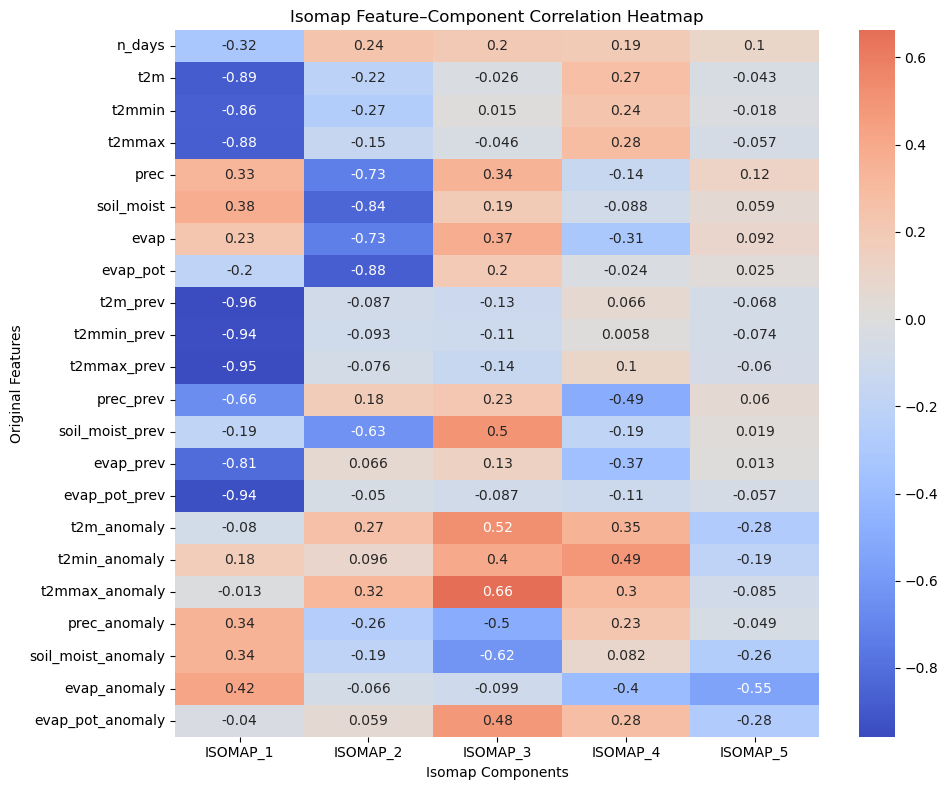

In [ ]:
# Compute correlations between original features and isomap components
components_df = pd.DataFrame(X_resl_isomap, 
                             columns=[f"ISOMAP_{i+1}" for i in range(5)])

features_df = pd.DataFrame(X_train_scaled, columns=feature_names)

corr_df = features_df.corrwith(components_df, axis=0)

# Full correlation matrix
corr_matrix = pd.concat(
    [features_df.corrwith(components_df[c], axis=0) for c in components_df],
    axis=1
)
corr_matrix.columns = components_df.columns

# Plot heatmap 
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Isomap Feature–Component Correlation Heatmap')
plt.xlabel('Isomap Components')
plt.ylabel('Original Features')
plt.tight_layout()
plt.show()


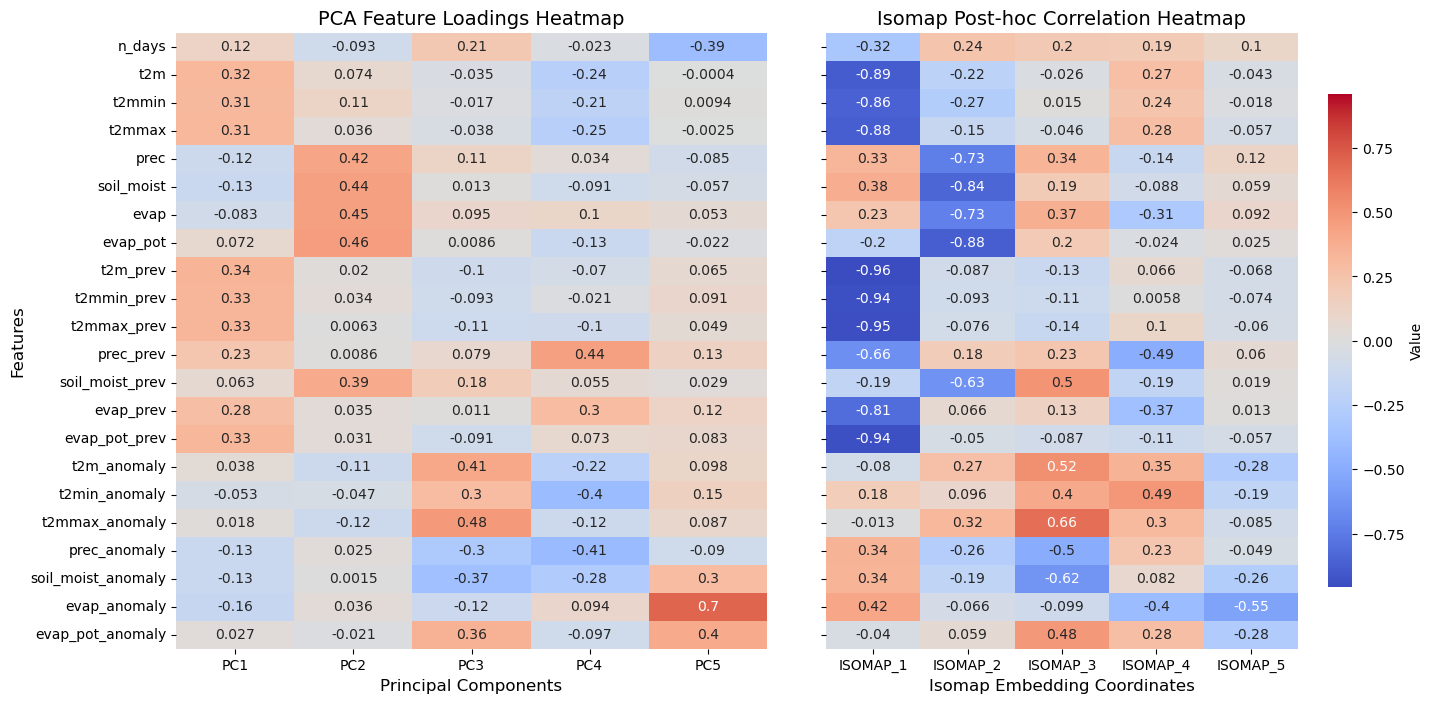

In [31]:
# Find the global min and max values across both datasets
vmin = min(loadings_df.min().min(), corr_matrix.min().min())
vmax = max(loadings_df.max().max(), corr_matrix.max().max())
# Make the scale symmetric around 0
vabs = max(abs(vmin), abs(vmax))
vmin, vmax = -vabs, vabs

# Get the number of columns (components) in each dataframe
n_pca_cols = loadings_df.shape[1]
n_isomap_cols = corr_matrix.shape[1]

# Create figure with width ratios proportional to number of columns
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8), sharey=True,
                                gridspec_kw={'width_ratios': [n_pca_cols, n_isomap_cols]})

# Plot PCA heatmap
sns.heatmap(loadings_df, annot=True, cmap='coolwarm', center=0,
            vmin=vmin, vmax=vmax, ax=ax1, cbar=False)
ax1.set_title('PCA Feature Loadings Heatmap', fontsize=14)
ax1.set_xlabel('Principal Components', fontsize=12)
ax1.set_ylabel('Features', fontsize=12)

# Plot Isomap heatmap
heatmap2 = sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0,
                       vmin=vmin, vmax=vmax, ax=ax2, cbar=True,
                       cbar_kws={"shrink": 0.8, "label": "Value"})
ax2.set_title('Isomap Post-hoc Correlation Heatmap', fontsize=14)
ax2.set_xlabel('Isomap Embedding Coordinates', fontsize=12)

# Adjust spacing between subplots
plt.subplots_adjust(wspace=0.1)
plt.show()